# Module 8: Scaling — Practice Problems

এই notebook-এ real datasets ব্যবহার করে scaling-এর সব concepts practice করা হবে।

**Datasets used:**
- California Housing Dataset
- Diabetes Dataset
- Breast Cancer Dataset
- Wine Dataset

সব dataset sklearn থেকে directly load করা যাবে — কোনো external file লাগবে না।

---
## Setup — Run this first

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_diabetes, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

print('Setup complete!')

Setup complete!


---
# Part 1: Why Scaling Matters
**Dataset: California Housing**

### Problem 1
California Housing dataset load করো এবং একটি DataFrame বানাও।
প্রতিটি feature-এর min, max এবং mean print করো।
দেখো feature-গুলোর range কতটা আলাদা।

In [3]:
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Your code here: print min, max, mean of each feature
df_housing.agg(['mean', 'max', 'min'])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000


### Problem 2
California Housing dataset-এর সব features-এর distribution একসাথে plot করো (histogram)।
কোন features-এর range সবচেয়ে বড়? কোনটা সবচেয়ে ছোট? চিহ্নিত করো।

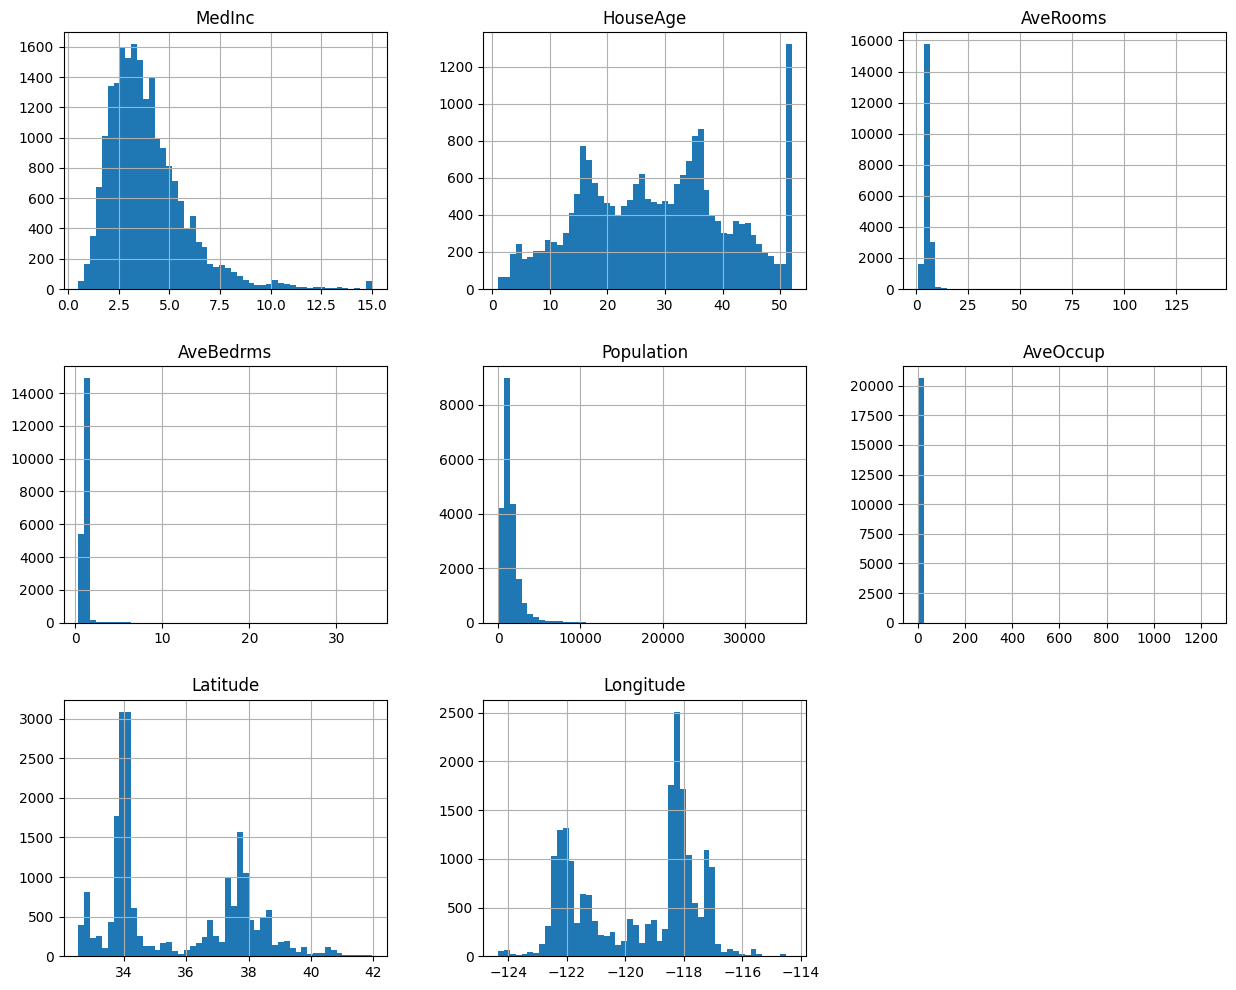

In [4]:
# Your code here: plot histogram for all features
df_housing.hist(bins=50, figsize=(15, 12))
plt.show()

In [5]:
# Answer:
# Features like 'Population' and 'HouseAge' have very large ranges (3 to 35682).
# Features like 'AveBedrms' and 'MedInc' have much smaller ranges (0.33 to 34).

### Problem 3
Diabetes dataset load করো। Features-এর scale দেখে বলো —
scaling ছাড়া কোন ধরনের ML model সবচেয়ে বেশি সমস্যায় পড়বে এবং কেন?
(KNN, Decision Tree — এই তিনটির মধ্যে তুলনা করো।)

In [6]:
# Load diabetes dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Your code here: explore and answer
print(df_diabetes.describe().loc[['min', 'max']])

          age       sex       bmi        bp        s1        s2        s3  \
min -0.107226 -0.044642 -0.090275 -0.112399 -0.126781 -0.115613 -0.102307   
max  0.110727  0.050680  0.170555  0.132044  0.153914  0.198788  0.181179   

           s4        s5        s6  
min -0.076395 -0.126097 -0.137767  
max  0.185234  0.133597  0.135612  


In [7]:
# Answer:
# KNN (K-Nearest Neighbors) will suffer the most without scaling. KNN uses distance
# metrics (like Euclidean distance). If a feature has a massive range, it will dominate
# the distance calculation, making the model ignore features with smaller ranges.
# Decision Trees, on the other hand, split based on one feature at a time,
# so they are scale-invariant and won't be affected.

---
# Part 2: Standard Scaling
**Dataset: Breast Cancer**

### Problem 4
Breast Cancer dataset load করো এবং train-test split করো (test_size=0.2, random_state=42)।
এরপর StandardScaler দিয়ে শুধু training data-তে fit করো এবং দুটোতেই transform করো।

In [33]:
# Load dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

# Your code here: train-test split, fit StandardScaler on train, transform both
X_train, X_test, y_train, y_test = train_test_split(df_cancer, y_cancer, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
y_test_scaled = scaler.transform(X_test)


### Problem 5
Problem 4-এর scaled training data-র mean এবং standard deviation print করো।
Expected output: mean ≈ 0, std ≈ 1।
যদি এই output না পাও, কোথায় ভুল হয়েছে খুঁজে বের করো।

In [45]:
# Your code here: verify mean and std after scaling
print(np.round(X_train_scaled.mean(axis=0)), 2)
print(np.round(X_train_scaled.std(axis=0)), 2)

[-0. -0. -0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0.
 -0.  0.  0. -0. -0. -0.  0. -0. -0.  0.  0. -0.] 2
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.] 2


### Problem 6
Breast Cancer dataset-এর যেকোনো একটি feature নিয়ে scaling-এর আগে এবং পরে
KDE plot পাশাপাশি (subplot) দেখাও।
Shape কি একই থাকে নাকি বদলে যায়?

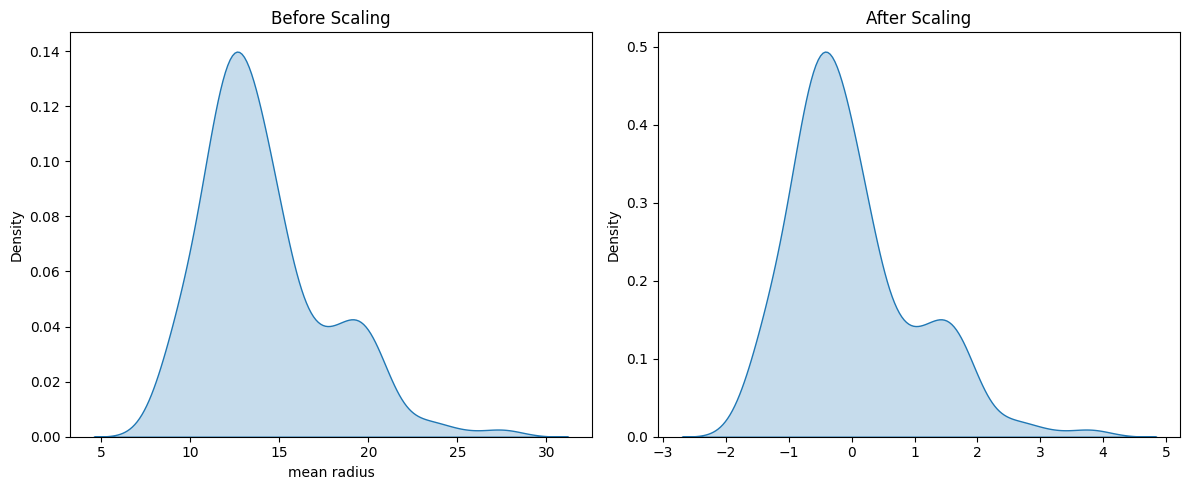

In [65]:
# Your code here: before vs after KDE plot side by side


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(X_train.iloc[:, 0], ax=axes[0], fill=True)
axes[0].set_title('Before Scaling')



sns.kdeplot(X_train_scaled[:, 0], ax=axes[1], fill=True)
axes[1].set_title('After Scaling')

plt.tight_layout()
plt.show()


### Problem 7
StandardScaler manually implement করো — sklearn ব্যবহার না করে।
formula: z = (x - mean) / std
Diabetes dataset-এর 'bmi' column-এ apply করো এবং sklearn-এর output-এর সাথে মিলিয়ে দেখো।

In [104]:
# Your code here: manual StandardScaler and compare with sklearn

bmi = df_diabetes['bmi']
manual_scaled_bmi_z = (bmi - bmi.mean()) / bmi.std(ddof=0)

ss = StandardScaler()
df_diabetes['bmi'] = sklearn_scaler.fit_transform(df_diabetes[['bmi']]).ravel()


comparison_df = pd.concat([manual_scaled_bmi_z.rename('Manual_Scaled'), df_diabetes['bmi'].rename('Sklearn_Scaled')], axis=1)
display(comparison_df)


,Manual_Scaled,Sklearn_Scaled
0,1.297088,1.297088
1,-1.082180,-1.082180
2,0.934533,0.934533
3,-0.243771,-0.243771
4,-0.764944,-0.764944
...,...,...
437,0.413360,0.413360
438,-0.334410,-0.334410
439,-0.334410,-0.334410
440,0.821235,0.821235


---
# Part 3: MinMax Scaling
**Dataset: Wine**

### Problem 8
Wine dataset load করো। MinMaxScaler apply করো সব features-এ।
Scaled data-র min এবং max verify করো — সব feature-এ min=0 এবং max=1 হওয়া উচিত।

In [117]:
# Load dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Your code here: apply MinMaxScaler and verify min/max
mm_scaler = MinMaxScaler()
wine_scaled = mm_scaler.fit_transform(df_wine)

print(np.round(wine_scaled.min(axis=0), 2))
print(np.round(wine_scaled.max(axis=0), 2))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Problem 9
MinMaxScaler manually implement করো — sklearn ব্যবহার না করে।
formula: x_scaled = (x - min) / (max - min)
Wine dataset-এর 'alcohol' column-এ apply করো এবং sklearn output-এর সাথে তুলনা করো।

In [131]:
# Your code here: manual MinMaxScaler and compare with sklearn
alcohol = df_wine['alcohol']
manual_minmax = (alcohol - alcohol.min()) / (alcohol.max() - alcohol.min())

smn = MinMaxScaler()
df_wine['alcohol'] = smn.fit_transform(df_wine[['alcohol']])

comparison_df = pd.concat([manual_minmax.rename('Manual_Scaled'), df_wine['alcohol'].rename('Sklearn_Scaled')], axis=1)
display(comparison_df)

,Manual_Scaled,Sklearn_Scaled
0,0.842105,0.842105
1,0.571053,0.571053
2,0.560526,0.560526
3,0.878947,0.878947
4,0.581579,0.581579
...,...,...
173,0.705263,0.705263
174,0.623684,0.623684
175,0.589474,0.589474
176,0.563158,0.563158


### Problem 10
Wine dataset-এ একটি artificial outlier যোগ করো (যেমন: alcohol = 500)।
MinMaxScaler apply করার পর দেখো বাকি সব values কীভাবে প্রভাবিত হয়।
Before এবং after plot করো।

Text(0.5, 1.0, 'After')

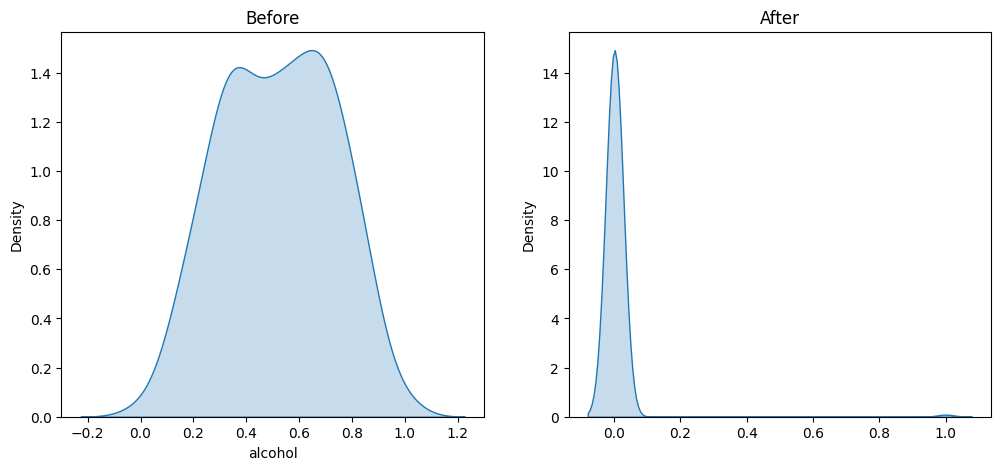

In [168]:
# Your code here: add outlier, apply MinMaxScaler, plot before vs after

df_wine_outlier = df_wine.copy()
df_wine_outlier.loc[0, 'alcohol'] = 500

mns = MinMaxScaler()

wine_mns_scaled = mns.fit_transform(df_wine_outlier)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(df_wine['alcohol'], ax=axes[0], fill=True)
axes[0].set_title('Before')

sns.kdeplot(wine_mm_scaled[:, 0], ax=axes[1], fill=True)
axes[1].set_title('After')

### Problem 11
একই outlier-যুক্ত Wine data-তে এবার StandardScaler apply করো।
MinMaxScaler vs StandardScaler — কোনটা outlier-এ বেশি ক্ষতিগ্রস্ত হয়েছে?
দুটির output plot করে তুলনা করো।

Text(0.5, 1.0, 'StandardScaler  with Outlier')

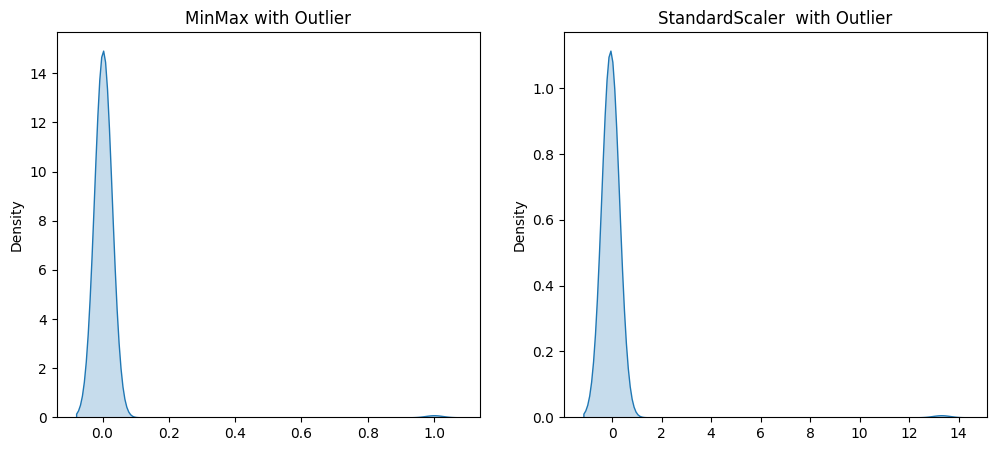

In [172]:
# Your code here: compare MinMaxScaler vs StandardScaler with outlier present
std_scaler = StandardScaler()
wine_std_scaled = std_scaler.fit_transform(df_wine_outlier)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(wine_mns_scaled[:, 0], ax=axes[0], fill=True)
axes[0].set_title('MinMax with Outlier')

sns.kdeplot(wine_std_scaled[:, 0], ax=axes[1], fill=True)
axes[1].set_title('StandardScaler  with Outlier')

In [173]:
# Answer: MinMaxScaler is much more damaged by the outlier because it uses the absolute min/max values.

---
# Part 4: Robust Scaler
**Dataset: California Housing**

### Problem 12
California Housing dataset-এ 'AveRooms' column-এ RobustScaler apply করো।
Scaled data-র median এবং IQR print করো।
Expected: median ≈ 0।

In [212]:
# Your code here: RobustScaler on AveRooms, check median and IQR
ave_rooms = df_housing['AveRooms']

# Sklearn
rb_scaler = RobustScaler()
sklearn_robust = rb_scaler.fit_transform(df_housing[['AveRooms']]).flatten()

print("Median:", np.median(sklearn_robust))
q75, q25 = np.percentile(sklearn_robust, [75, 25])
print("IQR:", q75 - q25)


Median: 0.0
IQR: 1.0000000000000002


### Problem 13
RobustScaler manually implement করো।
formula: x_scaled = (x - median) / IQR
California Housing-এর 'AveOccup' column-এ apply করো এবং sklearn output-এর সাথে মিলিয়ে দেখো।

In [213]:
# Your code here: manual RobustScaler and compare with sklearn

# Manual
median_val = ave_rooms.median()
iqr_val = ave_rooms.quantile(0.75) - ave_rooms.quantile(0.25)
manual_robust = (ave_rooms - median_val) / iqr_val

print("Median:", np.median(manual_robust))
q75, q25 = np.percentile(manual_robust, [75, 25])
print("IQR:", q75 - q25)


Median: 0.0
IQR: 1.0000000000000002


In [214]:
print("Are they identical?", np.allclose(manual_robust, sklearn_robust))

Are they identical? True


### Problem 14
California Housing-এর 'AveRooms' column-এ তিনটি scaler একসাথে compare করো:
StandardScaler, MinMaxScaler, RobustScaler।
তিনটির output এর KDE plot পাশাপাশি (3 subplots) দেখাও।
কোনটা outlier-এ সবচেয়ে কম প্রভাবিত হয়েছে?

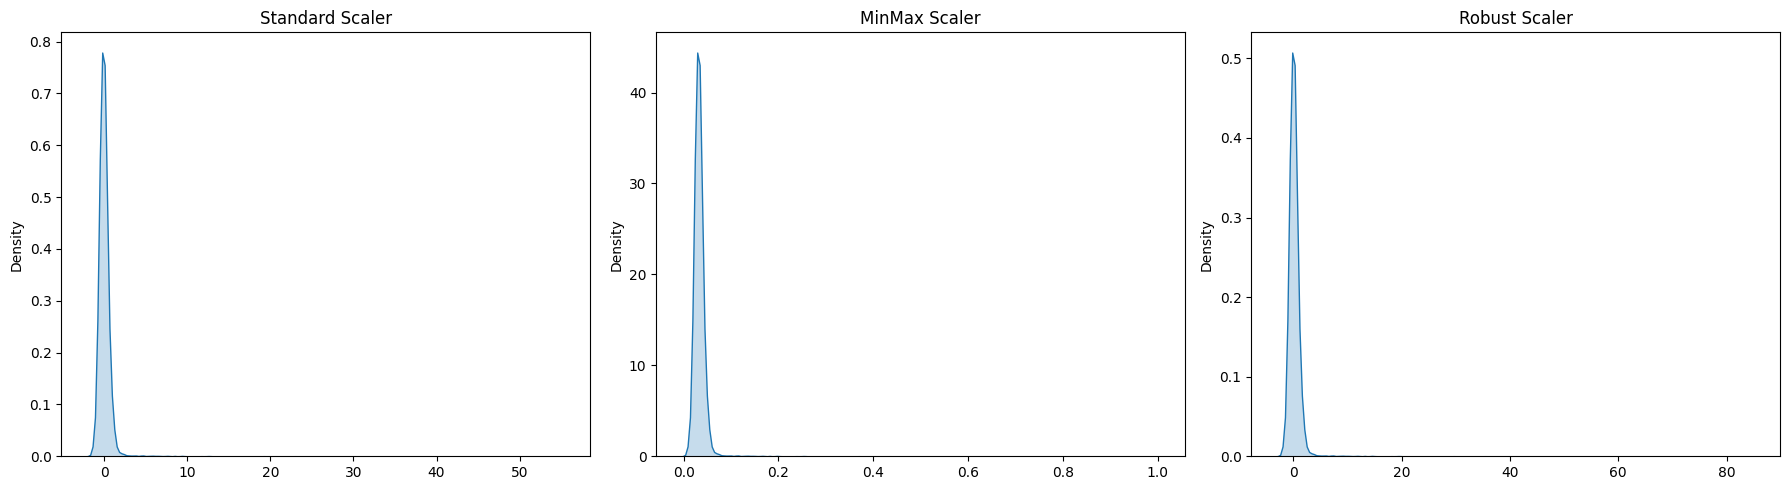

In [202]:
# Your code here: compare all 3 scalers side by side with KDE plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# StandardScaler
std_scaled = StandardScaler().fit_transform(df_housing[['AveRooms']]).flatten()
sns.kdeplot(std_scaled.flatten(), ax=axes[0], fill=True)
axes[0].set_title('Standard Scaler')

# MinMaxScaler
mm_scaled = MinMaxScaler().fit_transform(df_housing[['AveRooms']]).flatten()
sns.kdeplot(mm_scaled.flatten(), ax=axes[1], fill=True)
axes[1].set_title('MinMax Scaler')

# RobustScaler
rb_scaled = RobustScaler().fit_transform(df_housing[['AveRooms']]).flatten()
sns.kdeplot(rb_scaled.flatten(), ax=axes[2], fill=True)
axes[2].set_title('Robust Scaler')

plt.tight_layout()
plt.show()

In [ ]:
# RobustScaler is least affected because its calculations (Median/IQR) ignore extreme outliers entirely.

### Problem 15
Data leakage experiment করো:
- Case A: Scaler শুধু train data-তে fit করো, test-এ transform করো।
- Case B: Scaler পুরো dataset-এ fit করো, তারপর split করো।

Diabetes dataset ব্যবহার করো। দুই case-এ test set-এর mean এবং std print করো।
পার্থক্য দেখাও এবং কোনটা সঠিক তা explain করো।

In [220]:
X_train, X_test = train_test_split(df_diabetes, test_size=0.2, random_state=42)

# Case A: Correct Approach (Fit on train, transform test)
scaler_A = StandardScaler()
scaler_A.fit(X_train)
test_A = scaler_A.transform(X_test)

# Case B: Wrong Approach (Data Leakage - fit on full dataset)
scaler_B = StandardScaler()
full_scaled = scaler_B.fit_transform(df_diabetes)

_, test_B = train_test_split(full_scaled, test_size=0.2, random_state=42)

print("Case A (Correct) Test Mean:\n", np.round(test_A.mean(axis=0), 4)[:5]) # First 5 features
print("Case B (Leaked) Test Mean:\n", np.round(test_B.mean(axis=0), 4)[:5])



# Your code here: demonstrate data leakage vs correct approach
# Why is Case A correct? In the real world, you do not know the distribution of future unseen data.
# Fitting on the entire dataset "leaks" knowledge of the test set's distribution into your training process.

Case A (Correct) Test Mean:
 [-0.1548 -0.0192 -0.1826 -0.121   0.0578]
Case B (Leaked) Test Mean:
 [-0.1202 -0.0153 -0.1447 -0.0983  0.0463]


---
# Part 5: ColumnTransformer
**Dataset: California Housing**

### Problem 16
California Housing dataset-এ নিচের transformation apply করো ColumnTransformer দিয়ে:
- 'MedInc', 'AveRooms' → StandardScaler
- 'Latitude', 'Longitude' → MinMaxScaler
- বাকি সব columns → passthrough (কোনো change নেই)

Train-test split করে শুধু train-এ fit করো।

In [222]:
# Your code here: ColumnTransformer with mixed scaling
X_train_h, X_test_h = train_test_split(df_housing, test_size=0.2, random_state=42)

ct = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['MedInc', 'AveRooms']),
        ('minmax', MinMaxScaler(), ['Latitude', 'Longitude']),
    ],
    remainder='passthrough'
)

# Fit on train, transform
X_train_transformed = ct.fit_transform(X_train_h)
print("Shape of output:", X_train_transformed.shape)
print("First 2 rows:\n", np.round(X_train_transformed[:2], 3))

Shape of output: (16512, 8)
First 2 rows:
 [[-3.260e-01 -1.750e-01  1.700e-02  7.290e-01  3.300e+01  1.006e+00
   2.300e+03  3.692e+00]
 [-3.600e-02 -4.030e-01  1.300e-01  6.170e-01  4.900e+01  1.041e+00
   1.314e+03  1.738e+00]]


### Problem 17
Problem 16-এর ColumnTransformer-এ RobustScaler যোগ করো:
- 'AveOccup', 'AveBedrms' → RobustScaler

এখন তিনটি scaler একই pipeline-এ আছে।
Output DataFrame-এর shape এবং প্রথম 5 rows print করো।

In [228]:
# Your code here: ColumnTransformer with all 3 scalers
X_train_h, X_test_h = train_test_split(df_housing, test_size=0.2, random_state=42)

ct = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), ['AveOccup', 'AveBedrms'])
    ],
    remainder='passthrough'
)

# Fit on train, transform
X_train_transformed = ct.fit_transform(X_train_h)
print("Shape of output:", X_train_transformed.shape)
print("First 2 rows:\n", np.round(X_train_transformed[:2], 3))


Shape of output: (16512, 8)
First 2 rows:
 [[ 1.0270e+00 -4.5700e-01  3.2600e+00  3.3000e+01  5.0180e+00  2.3000e+03
   3.2710e+01 -1.1703e+02]
 [-1.2680e+00 -8.8000e-02  3.8120e+00  4.9000e+01  4.4740e+00  1.3140e+03
   3.3770e+01 -1.1816e+02]]


### Problem 18
ColumnTransformer-এর `remainder='drop'` এবং `remainder='passthrough'` এর পার্থক্য কী?
California Housing dataset-এ দুটি case try করো এবং output shape তুলনা করো।

In [230]:
# Your code here: compare remainder='drop' vs remainder='passthrough'
ct_drop = ColumnTransformer(
    transformers=[('std', StandardScaler(), ['MedInc'])],
    remainder='drop'
)
ct_pass = ColumnTransformer(
    transformers=[('std', StandardScaler(), ['MedInc'])],
    remainder='passthrough'
)

drop_shape = ct_drop.fit_transform(X_train_h).shape
pass_shape = ct_pass.fit_transform(X_train_h).shape

print(f"Drop Shape: {drop_shape}")       # Only keeps 'MedInc' (1 column)
print(f"Passthrough Shape: {pass_shape}") # Keeps all 8 columns

Drop Shape: (16512, 1)
Passthrough Shape: (16512, 8)


### Problem 19
Wine dataset-এ সব numeric features-এ StandardScaler apply করো ColumnTransformer দিয়ে।
এরপর `set_output(transform='pandas')` ব্যবহার করে output-কে DataFrame হিসেবে রাখো।
Column names ঠিক আছে কিনা verify করো।

In [236]:
# Your code here: ColumnTransformer with set_output pandas
ct_pandas = ColumnTransformer(
    transformers=[('std', StandardScaler(), df_wine.columns)],
    remainder='drop'
).set_output(transform='pandas')

wine_transformed_df = ct_pandas.fit_transform(df_wine)
print("Columns maintained:", wine_transformed_df.columns.tolist()[:3])
wine_transformed_df.head()

Columns maintained: ['std__alcohol', 'std__malic_acid', 'std__ash']


,std__alcohol,std__malic_acid,std__ash,std__alcalinity_of_ash,std__magnesium,std__total_phenols,std__flavanoids,std__nonflavanoid_phenols,std__proanthocyanins,std__color_intensity,std__hue,std__od280/od315_of_diluted_wines,std__proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


---
# Part 6: End-to-End Challenge Problems
এই problems-গুলো সব concepts একসাথে ব্যবহার করে।

### Problem 20 ⭐
Breast Cancer dataset নিয়ে পুরো preprocessing pipeline তৈরি করো:
1. Train-test split (80-20)
2. তিনটি scaler আলাদা আলাদাভাবে apply করো
3. প্রতিটি scaler-এর পর mean এবং std print করো
4. কোন scaler-এর output সবচেয়ে stable সেটা বলো

শুধু train-এ fit করতে ভুলো না।

In [240]:
# Your code here: full pipeline with all 3 scalers
X_train, X_test = train_test_split(df_cancer, test_size=0.2, random_state=42)

scalers = {'Standard': StandardScaler(), 'MinMax': MinMaxScaler(), 'Robust': RobustScaler()}

for name, scaler in scalers.items():
    scaled_train = scaler.fit_transform(X_train)
    print(f"--------{name} Scaler--------")
    print(f"Mean : {np.round(np.mean(scaled_train), 3)}, STD: {np.round(np.std(scaled_train), 3)}")

# Standard Scaler usually provides the most uniformly stable output mathematically (Mean 0, Std 1)
# across features that are largely normally distributed.

--------Standard Scaler--------
Mean : -0.0, STD: 1.0
--------MinMax Scaler--------
Mean : 0.24, STD: 0.175
--------Robust Scaler--------
Mean : 0.211, STD: 0.968


In [241]:
# Standard Scaler usually provides the most uniformly stable output mathematically (Mean 0, Std 1)
# across features that are largely normally distributed.

### Problem 21 ⭐
California Housing dataset-এ outlier detection করো:
1. 'AveOccup' column-এর boxplot দেখাও
2. IQR method দিয়ে outlier চিহ্নিত করো
3. Outlier সরানোর আগে এবং পরে StandardScaler apply করো
4. দুই ক্ষেত্রে scaled data-র describe() তুলনা করো

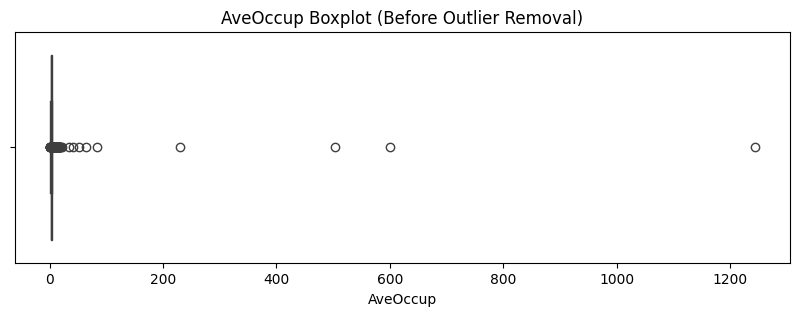

Original Data Rows: 20640
Cleaned Data Rows: 19929

With Outliers Std: 1.0
Without Outliers Std: 1.0


,With_Outliers,Without_Outliers
count,2.064000e+04,1.992900e+04
mean,3.442552e-18,2.110699e-16
std,1.000024e+00,1.000025e+00
min,-2.290000e-01,-2.681192e+00
25%,-6.171062e-02,-6.787311e-01
50%,-2.431585e-02,-7.747663e-02
75%,2.037453e-02,6.058588e-01
max,1.194191e+02,2.743257e+00


In [249]:
# Your code here: outlier detection and scaling comparison
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_housing['AveOccup'])
plt.title('AveOccup Boxplot (Before Outlier Removal)')
plt.show()

#IQR Method
Q1 = df_housing['AveOccup'].quantile(0.25)
Q3 = df_housing['AveOccup'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier রিমুভ করা
df_housing_clean = df_housing[(df_housing['AveOccup'] >= lower_bound) & (df_housing['AveOccup'] <= upper_bound)]

print(f"Original Data Rows: {len(df_housing)}")
print(f"Cleaned Data Rows: {len(df_housing_clean)}\n")

#StandardScaler অ্যাপ্লাই করা
scaler = StandardScaler()
scaled_with_outliers = scaler.fit_transform(df_housing[['AveOccup']])
scaled_without_outliers = scaler.fit_transform(df_housing_clean[['AveOccup']])

#scaled data-র describe() তুলনা করা
df_with = pd.DataFrame(scaled_with_outliers, columns=['With_Outliers'])
df_without = pd.DataFrame(scaled_without_outliers, columns=['Without_Outliers'])

print("With Outliers Std:", scaled_with_outliers.std())
print("Without Outliers Std:", scaled_without_outliers.std())

comparison_df = pd.concat([df_with.describe(), df_without.describe()], axis=1)
display(comparison_df)

# Notice the data's core distribution is better represented without outliers inflating the variance.

### Problem 22 ⭐
নিচের scenario-তে কোন scaler ব্যবহার করবে এবং কেন — code দিয়ে prove করো:

- Scenario A: Diabetes dataset-এর 'bmi' — normally distributed, কোনো extreme outlier নেই
- Scenario B: California Housing-এর 'AveOccup' — heavily skewed, extreme outliers আছে
- Scenario C: Wine dataset-এর 'alcohol' — neural network-এ input দেওয়া হবে

প্রতিটিতে correct scaler apply করো এবং output plot করো।

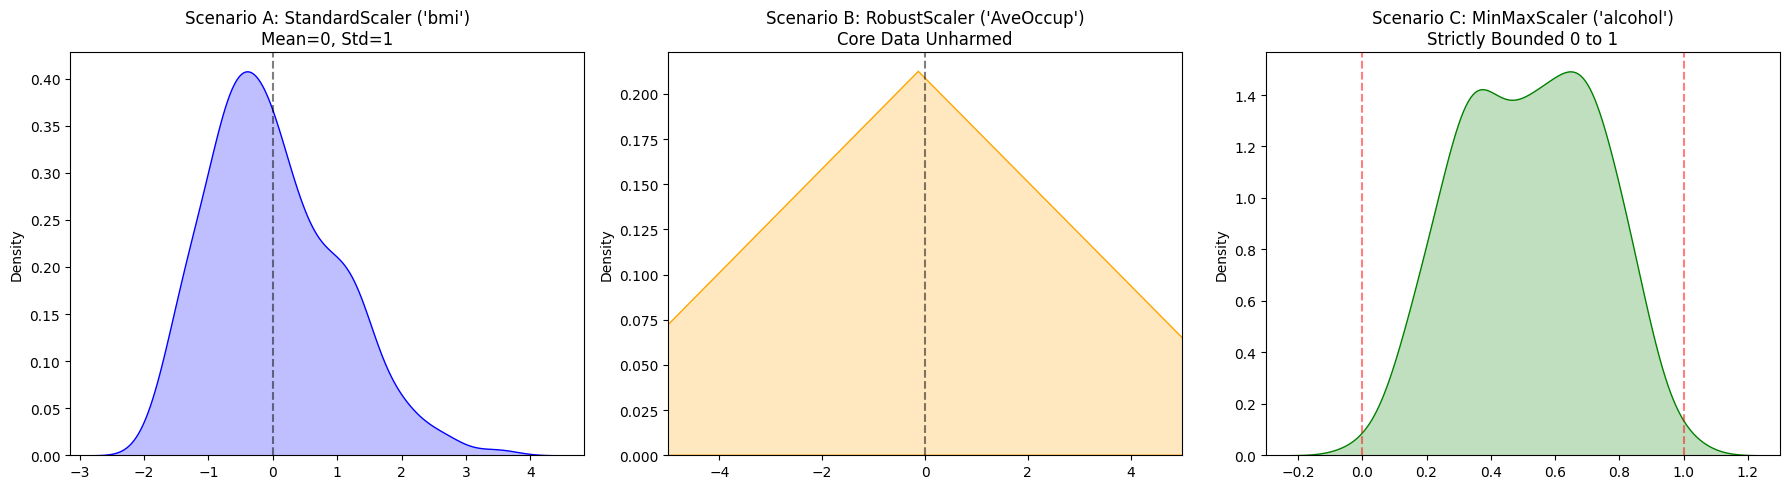

--- Statistical Proof ---
Scenario A (StandardScaler) -> Mean: -0.0, Std: 1.0
Scenario C (MinMaxScaler)   -> Min: 0.0, Max: 1.0


In [266]:
# Your code here: choose correct scaler for each scenario

# Scenario A: StandardScaler (Normally distributed)
std_scaler = StandardScaler()
scaled_bmi = std_scaler.fit_transform(df_diabetes[['bmi']])

# Scenario B: RobustScaler (Heavy outliers)
robust_scaler = RobustScaler()
scaled_aveoccup = robust_scaler.fit_transform(df_housing[['AveOccup']])

# Scenario C: MinMaxScaler (Bounded input for Neural Network)
minmax_scaler = MinMaxScaler()
scaled_alcohol = minmax_scaler.fit_transform(df_wine[['alcohol']])



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: StandardScaler
sns.kdeplot(scaled_bmi.flatten(), ax=axes[0], fill=True, color='blue')
axes[0].set_title("Scenario A: StandardScaler ('bmi')\nMean=0, Std=1")
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5) # Mean line

# Plot B: RobustScaler
# (Note: xlim সেট করা হয়েছে মূল ডিস্ট্রিবিউশনটি দেখার জন্য, কারণ আউটলায়ারের কারণে চার্ট অনেক চওড়া হয়ে যায়)
sns.kdeplot(scaled_aveoccup.flatten(), ax=axes[1], fill=True, color='orange')
axes[1].set_title("Scenario B: RobustScaler ('AveOccup')\nCore Data Unharmed")
axes[1].set_xlim(-5, 5)
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5) # Median line

# Plot C: MinMaxScaler
sns.kdeplot(scaled_alcohol.flatten(), ax=axes[2], fill=True, color='green')
axes[2].set_title("Scenario C: MinMaxScaler ('alcohol')\nStrictly Bounded 0 to 1")
axes[2].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[2].axvline(1, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


print("--- Statistical Proof ---")
print(f"Scenario A (StandardScaler) -> Mean: {np.round(scaled_bmi.mean(), 2)}, Std: {np.round(scaled_bmi.std(), 2)}")
print(f"Scenario C (MinMaxScaler)   -> Min: {scaled_alcohol.min()}, Max: {scaled_alcohol.max()}")

### Problem 23 ⭐
California Housing dataset-এ একটি complete ColumnTransformer pipeline তৈরি করো:
- 'MedInc' → StandardScaler (normally distributed income)
- 'Latitude', 'Longitude' → MinMaxScaler (geographic coordinates for neural net)
- 'AveOccup', 'AveRooms' → RobustScaler (skewed with outliers)
- বাকি columns → passthrough

Train-test split করে properly fit ও transform করো।
Final X_train এবং X_test shape print করো।

In [267]:
# Your code here: complete ColumnTransformer pipeline
X_train, X_test = train_test_split(df_housing, test_size=0.2, random_state=42)

final_ct = ColumnTransformer([
    ('std', StandardScaler(), ['MedInc']),
    ('minmax', MinMaxScaler(), ['Latitude', 'Longitude']),
    ('robust', RobustScaler(), ['AveOccup', 'AveRooms'])
],remainder='passthrough'
)

X_train_final = final_ct.fit_transform(X_train)
X_test_final = final_ct.transform(X_test)

print(f"X_train shape: {X_train_final.shape}")
print(f"X_test shape: {X_test_final.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)


### Problem 24 ⭐
Scaler-এর inverse_transform কী কাজ করে?
Wine dataset-এ StandardScaler apply করো।
এরপর inverse_transform দিয়ে original values ফিরিয়ে আনো।
Original এবং recovered values কি same? Verify করো।

In [268]:
# Your code here: apply StandardScaler and then inverse_transform
scaler_inv = StandardScaler()
wine_scaled = scaler_inv.fit_transform(df_wine)
wine_recovered = scaler_inv.inverse_transform(wine_scaled)

# Verify if they are the exact same
print("Data fully recovered:", np.allclose(df_wine, wine_recovered))

Data fully recovered: True


### Problem 25 ⭐
Final challenge: Data leakage এর real impact দেখাও।

Diabetes dataset-এ:
- Case A (Correct): train-এ fit, test-এ transform
- Case B (Wrong): full data-তে fit, তারপর split

দুই case-এ test set-এর scaled values-এর mean ও std compare করো।
পার্থক্য কতটুকু? Real-world-এ এই পার্থক্য কেন সমস্যা তৈরি করে সেটা comment-এ লেখো।

In [271]:
# Your code here: demonstrate real impact of data leakage
X_train_A, X_test_A = train_test_split(df_diabetes, test_size=0.2, random_state=42)

scaler_A = StandardScaler()
scaler_A.fit(X_train_A)               # শুধুমাত্র train data-তে fit করা হলো
test_A_scaled = scaler_A.transform(X_test_A) # test data-কে শুধু transform করা হলো

# Case B: Wrong Approach (Full data-তে fit, তারপর split -> Data Leakage!)
scaler_B = StandardScaler()
df_diabetes_scaled_full = scaler_B.fit_transform(df_diabetes) # পুরো ডেটাতে fit ও transform

# একই random_state ব্যবহার করে split, যেন ডেটা পয়েন্টগুলো হুবহু সেম থাকে
_, test_B_scaled = train_test_split(df_diabetes_scaled_full, test_size=0.2, random_state=42)

# Test set-এর Mean এবং Std ক্যালকুলেট করা
mean_A = test_A_scaled.mean(axis=0)
mean_B = test_B_scaled.mean(axis=0)
std_A = test_A_scaled.std(axis=0)
std_B = test_B_scaled.std(axis=0)

# পার্থক্য (Absolute Difference) বের করা
mean_diff = np.abs(mean_A - mean_B)
std_diff = np.abs(std_A - std_B)

# পার্থক্যগুলো সুন্দরভাবে তুলনামূলক টেবিলে দেখানোর জন্য
leakage_impact_df = pd.DataFrame({
    'Feature': df_diabetes.columns,
    'Correct_Test_Mean': mean_A,
    'Leaked_Test_Mean': mean_B,
    'Mean_Difference': mean_diff,
    'Std_Difference': std_diff
})

display(leakage_impact_df)

,Feature,Correct_Test_Mean,Leaked_Test_Mean,Mean_Difference,Std_Difference
0,age,-0.154759,-0.120227,0.034531,0.030641
1,sex,-0.019196,-0.015334,0.003862,0.000238
2,bmi,-0.182591,-0.144731,0.037860,0.007684
3,bp,-0.121016,-0.098345,0.022671,0.015879
4,s1,0.057815,0.046322,0.011493,0.003159
5,s2,0.084158,0.067210,0.016948,0.000031
6,s3,0.104555,0.082470,0.022085,0.013065
7,s4,-0.039187,-0.031399,0.007787,0.003246
8,s5,-0.126450,-0.101403,0.025047,0.003995
9,s6,-0.194390,-0.157685,0.036705,0.014192


💡 Real-world-এ এই পার্থক্য কেন সমস্যা তৈরি করে? (Comment)
১. ভবিষ্যতের ডেটা আগে থেকেই জেনে ফেলা (Peeking into the future): রিয়েল-ওয়ার্ল্ড প্রজেক্টে Test Set বলতে "ভবিষ্যতের সম্পূর্ণ নতুন ও অজানা ডেটা"-কে বোঝায়। তুমি যখন পুরো ডেটাসেটে (Train + Test) Scaler Fit করো, তখন তোমার Test Data-র Mean এবং Max/Min ভ্যালুগুলো স্কেলারের ক্যালকুলেশনে ঢুকে যায়। অর্থাৎ, ভবিষ্যতের ডেটার তথ্য মডেল ট্রেইনিংয়ের সময়ই "Leak" বা ফাঁস হয়ে যাচ্ছে।

২. প্রোডাকশনে (Production) মডেল ফেইল করা:
Data Leakage-এর কারণে লোকাল এনভায়রনমেন্টে তোমার মডেল টেস্ট সেটে অনেক ভালো অ্যাকুরেসি দেখাবে, কারণ টেস্ট সেটের বৈশিষ্ট্য স্কেলারের মাধ্যমে সে আগে থেকেই চিনে রেখেছে। কিন্তু যখন তুমি মডেলটিকে রিয়েল লাইফ সার্ভারে (যেমন: কোনো ওয়েব অ্যাপ বা স্ক্র্যাপিং পাইপলাইনে) ডিপ্লয় করবে এবং সম্পূর্ণ নতুন ডেটা আসতে শুরু করবে, তখন মডেলটি খুব বাজে পারফর্ম করবে। কারণ বাস্তবে ভবিষ্যৎ ডেটার Mean/Variance আগে থেকে জানার কোনো উপায় নেই।

গোল্ডেন রুল:
যেকোনো Preprocessing (Scaling, Imputation ইত্যাদি) সর্বদা শুধুমাত্র Training Data-তে .fit() বা .fit_transform() করতে হয় এবং Test বা Validation Data-তে শুধুমাত্র .transform() করতে হয়।